<a href="https://colab.research.google.com/github/ansaganakhat/project-1/blob/main/notebook2_bow_tfidf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(135deg, #1b5e20 0%, #2e7d32 50%, #388e3c 100%); padding: 40px 30px; border-radius: 12px; margin-bottom: 30px;">
  <h1 style="color:#ffffff; font-size:2.2em; font-weight:700; margin:0 0 10px 0;">Зертханалық Жұмыс 2</h1>
  <h2 style="color:#c8e6c9; font-size:1.4em; font-weight:400; margin:0 0 16px 0;">Bag of Words және TF-IDF</h2>
  <p style="color:#e8f5e9; font-size:1em; margin:0;">CountVectorizer · TfidfVectorizer · Мəтін Классификациясы · Ерекшелік Маңыздылығы</p>
</div>

## Кіріспе

**Bag of Words (BoW)** — мəтінді сөздердің жиілік векторына айналдырудың ең қарапайым əдісі. Идея: əр мəтін белгілі бір vocabulary-дағы сөздердің санын береді. Сөздердің реті ескерілмейді.

**TF-IDF** (Term Frequency — Inverse Document Frequency) — BoW-тің жетілдірілген нұсқасы. Сирек кездесетін, бірақ маңызды сөздерге жоғары мəн береді, ал жиі кездесетін (бірақ ақпаратсыз) сөздерді төмендетеді.

```
TF-IDF(t, d) = TF(t, d) × IDF(t)
IDF(t) = log(N / df(t))
```

## Оқу Мақсаттары

- BoW матрицасын қолмен жəне sklearn арқылы жасай аласыз
- TF-IDF мəнін формула бойынша есептей аласыз
- N-gram ерекшеліктерін (bigram, trigram) қоса аласыз
- Logistic Regression арқылы мəтін классификациясын орындай аласыз
- Ерекшелік маңыздылығын (feature importance) визуализациялай аласыз
- BoW мен TF-IDF нəтижелерін салыстыра аласыз

**Болжалды орындалу уақыты: 20 минут**

## 1-бөлім: Кітапханаларды Импорттау

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

print("Кітапханалар жүктелді.")

Кітапханалар жүктелді.


In [2]:
# ============================================================
### TODO ###
# TensorFlow нұсқасы орнына sklearn нұсқасын шығарыңыз.
# import sklearn; print(sklearn.__version__)
# ============================================================
import sklearn
print("sklearn нұсқасы:", sklearn.__version__)

sklearn нұсқасы: 1.6.1


## 2-бөлім: Bag of Words — Қолмен Іске Асыру

In [3]:
# Қарапайым мысал корпусы
corpus = [
    "the cat sat on the mat",
    "the dog sat on the floor",
    "the cat and the dog are friends",
    "the mat is on the floor",
]
print("Корпус:")
for i, doc in enumerate(corpus):
    print(f"  D{i+1}: {doc}")

Корпус:
  D1: the cat sat on the mat
  D2: the dog sat on the floor
  D3: the cat and the dog are friends
  D4: the mat is on the floor


In [4]:
# ============================================================
### TODO ###
# BoW матрицасын ҚОЛМЕН жасаңыз:
#   1) Барлық бірегей сөздерден vocabulary жасаңыз (sorted)
#   2) Əр құжат үшін сөздердің санын есептеп,
#      vocabulary өлшемді вектор жасаңыз
#   3) Нəтижені матрица ретінде шығарыңыз
# ============================================================
all_words  = set()
for doc in corpus:
    all_words.update(doc.split())
vocabulary = sorted(all_words)

bow_matrix = []
for doc in corpus:
    words  = doc.split()
    vector = [words.count(word) for word in vocabulary]
    bow_matrix.append(vector)

bow_matrix = np.array(bow_matrix)

print("Vocabulary:", vocabulary)
print(f"\nBoW матрицасы ({bow_matrix.shape}):")
df_bow = pd.DataFrame(bow_matrix, columns=vocabulary,
                      index=[f'D{i+1}' for i in range(len(corpus))])
print(df_bow)

Vocabulary: ['and', 'are', 'cat', 'dog', 'floor', 'friends', 'is', 'mat', 'on', 'sat', 'the']

BoW матрицасы ((4, 11)):
    and  are  cat  dog  floor  friends  is  mat  on  sat  the
D1    0    0    1    0      0        0   0    1   1    1    2
D2    0    0    0    1      1        0   0    0   1    1    2
D3    1    1    1    1      0        1   0    0   0    0    2
D4    0    0    0    0      1        0   1    1   1    0    2


In [5]:
# CountVectorizer арқылы тексереміз
cv = CountVectorizer()
X_cv = cv.fit_transform(corpus).toarray()

print("CountVectorizer vocabulary:")
print(cv.vocabulary_)
print(f"\nMatрица пішімі: {X_cv.shape}")

CountVectorizer vocabulary:
{'the': 10, 'cat': 2, 'sat': 9, 'on': 8, 'mat': 7, 'dog': 3, 'floor': 4, 'and': 0, 'are': 1, 'friends': 5, 'is': 6}

Matрица пішімі: (4, 11)


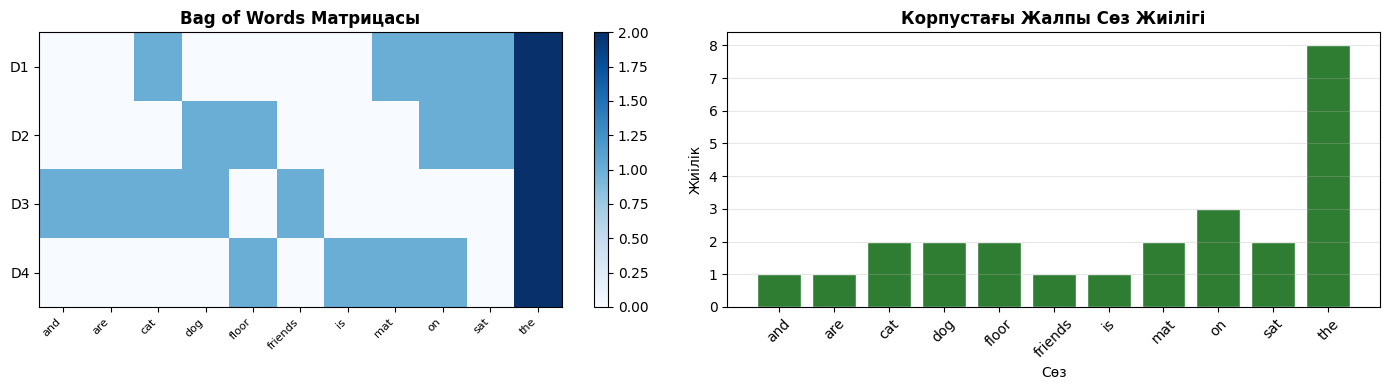

In [6]:
# BoW матрицасын жылу картасында бейнелейміз
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Қолмен жасалған BoW
im1 = axes[0].imshow(bow_matrix, cmap='Blues', aspect='auto')
axes[0].set_xticks(range(len(vocabulary)))
axes[0].set_xticklabels(vocabulary, rotation=45, ha='right', fontsize=8)
axes[0].set_yticks(range(len(corpus)))
axes[0].set_yticklabels([f'D{i+1}' for i in range(len(corpus))])
axes[0].set_title('Bag of Words Матрицасы', fontsize=12, fontweight='bold')
plt.colorbar(im1, ax=axes[0])

# Сөз жиілігінің таралуы
word_totals = bow_matrix.sum(axis=0)
axes[1].bar(vocabulary, word_totals, color='#2e7d32', edgecolor='white')
axes[1].set_title('Корпустағы Жалпы Сөз Жиілігі', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Сөз')
axes[1].set_ylabel('Жиілік')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 3-бөлім: TF-IDF — Формула бойынша Есептеу

**TF** (Term Frequency) — сөздің бір құжаттағы жиілігі:
```
TF(t, d) = count(t, d) / total_words(d)
```

**IDF** (Inverse Document Frequency) — сөздің барлық корпустағы сиректігі:
```
IDF(t) = log(1 + N) / (1 + df(t)) + 1   # sklearn нормализациясы
```

In [8]:
# ============================================================
### TODO ###
# TF-IDF мəнін ҚОЛМЕН есептеңіз:
#   1) Əр сөз үшін TF = count(t,d) / len(doc)
#   2) Əр сөз үшін df = сол сөз кездесетін құжаттар саны
#   3) IDF = log((1+N)/(1+df)) + 1
#   4) TF-IDF = TF × IDF
# ============================================================
N = len(corpus)

# df: əр сөз қанша құжатта кездеседі
df_counts = {}
for word in vocabulary:
    df_counts[word] = sum(1 for doc in corpus if word in doc.split())

# IDF есептеу
idf = {}
for word in vocabulary:
    idf[word] = np.log((1 + N) / (1 + df_counts[word])) + 1   # N

# TF-IDF матрицасы
tfidf_manual = []
for doc in corpus:
    words  = doc.split()
    tf_vec = [words.count(w) / len(words) for w in vocabulary]
    tfidf_vec = [tf * idf[w] for tf, w in zip(tf_vec, vocabulary)]
    tfidf_manual.append(tfidf_vec)

tfidf_manual = np.array(tfidf_manual)

df_tfidf = pd.DataFrame(tfidf_manual.round(4), columns=vocabulary,
                        index=[f'D{i+1}' for i in range(N)])
print("TF-IDF матрицасы (қолмен):")
print(df_tfidf)

TF-IDF матрицасы (қолмен):
       and     are     cat     dog   floor  friends      is     mat      on  \
D1  0.0000  0.0000  0.2518  0.0000  0.0000   0.0000  0.0000  0.2518  0.2039   
D2  0.0000  0.0000  0.0000  0.2518  0.2518   0.0000  0.0000  0.0000  0.2039   
D3  0.2738  0.2738  0.2158  0.2158  0.0000   0.2738  0.0000  0.0000  0.0000   
D4  0.0000  0.0000  0.0000  0.0000  0.2518   0.0000  0.3194  0.2518  0.2039   

       sat     the  
D1  0.2518  0.3333  
D2  0.2518  0.3333  
D3  0.0000  0.2857  
D4  0.0000  0.3333  


In [9]:
# sklearn TfidfVectorizer арқылы тексереміз
tfidf_vec = TfidfVectorizer()
X_tfidf   = tfidf_vec.fit_transform(corpus).toarray()

print("TfidfVectorizer нəтижесі:")
df_tfidf_sk = pd.DataFrame(X_tfidf.round(4),
                            columns=tfidf_vec.get_feature_names_out(),
                            index=[f'D{i+1}' for i in range(N)])
print(df_tfidf_sk)
print("\nЕскерту: sklearn нормализацияны əр жолға қолданады.")

TfidfVectorizer нəтижесі:
      and    are     cat     dog   floor  friends      is     mat      on  \
D1  0.000  0.000  0.4300  0.0000  0.0000    0.000  0.0000  0.4300  0.3481   
D2  0.000  0.000  0.0000  0.4300  0.4300    0.000  0.0000  0.0000  0.3481   
D3  0.433  0.433  0.3414  0.3414  0.0000    0.433  0.0000  0.0000  0.0000   
D4  0.000  0.000  0.0000  0.0000  0.4077    0.000  0.5171  0.4077  0.3301   

     sat     the  
D1  0.43  0.5693  
D2  0.43  0.5693  
D3  0.00  0.4520  
D4  0.00  0.5397  

Ескерту: sklearn нормализацияны əр жолға қолданады.


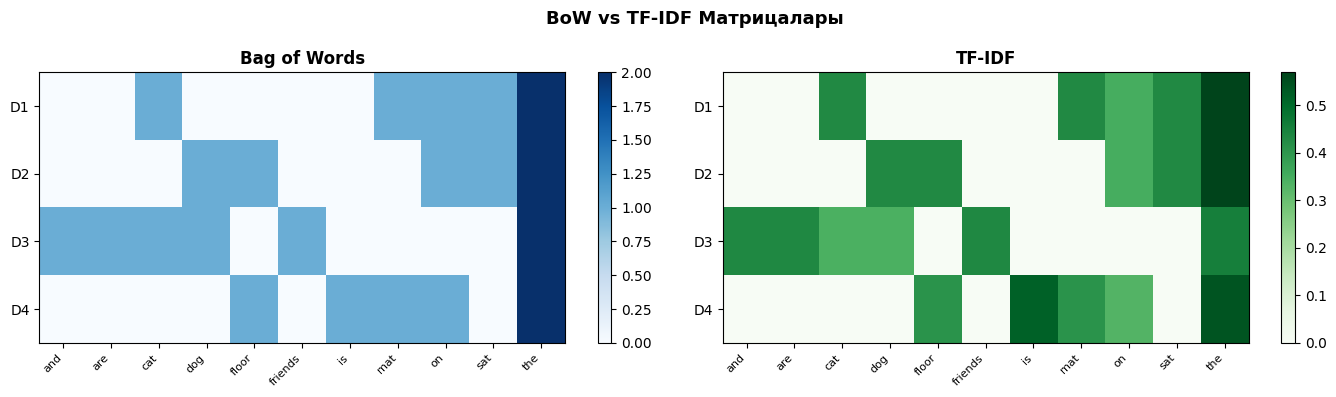

In [10]:
# ============================================================
### TODO ###
# BoW мен TF-IDF матрицаларын қатар бейнелеңіз.
# Имплот арқылы жылу картасы жасаңыз.
# BoW үшін: X_cv, TF-IDF үшін: X_tfidf пайдаланыңыз.
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

vocab_sk = tfidf_vec.get_feature_names_out()

im1 = ax1.imshow(X_cv, cmap='Blues', aspect='auto')    # X_cv
ax1.set_xticks(range(len(vocab_sk)))
ax1.set_xticklabels(vocab_sk, rotation=45, ha='right', fontsize=8)
ax1.set_yticks(range(N))
ax1.set_yticklabels([f'D{i+1}' for i in range(N)])
ax1.set_title('Bag of Words', fontsize=12, fontweight='bold')
plt.colorbar(im1, ax=ax1)

im2 = ax2.imshow(X_tfidf, cmap='Greens', aspect='auto')   # X_tfidf
ax2.set_xticks(range(len(vocab_sk)))
ax2.set_xticklabels(vocab_sk, rotation=45, ha='right', fontsize=8)
ax2.set_yticks(range(N))
ax2.set_yticklabels([f'D{i+1}' for i in range(N)])
ax2.set_title('TF-IDF', fontsize=12, fontweight='bold')
plt.colorbar(im2, ax=ax2)

plt.suptitle('BoW vs TF-IDF Матрицалары', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4-бөлім: N-gram Ерекшеліктері

In [11]:
# Bigram жəне Trigram
cv_ngram = CountVectorizer(ngram_range=(1, 2))   # unigram + bigram
X_ngram  = cv_ngram.fit_transform(corpus)

print(f"Unigram vocabulary өлшемі:         {len(cv.vocabulary_)}")
print(f"Unigram+Bigram vocabulary өлшемі:  {len(cv_ngram.vocabulary_)}")
print("\nMысал bigramдар:")
bigrams = [f for f in cv_ngram.get_feature_names_out() if ' ' in f]
print(bigrams)

Unigram vocabulary өлшемі:         11
Unigram+Bigram vocabulary өлшемі:  25

Mысал bigramдар:
['and the', 'are friends', 'cat and', 'cat sat', 'dog are', 'dog sat', 'is on', 'mat is', 'on the', 'sat on', 'the cat', 'the dog', 'the floor', 'the mat']


In [12]:
# ============================================================
### TODO ###
# TfidfVectorizer-ді ngram_range=(1,3) (unigram+bigram+trigram)
# параметрімен жасаңыз.
# Корпусқа fit_transform жасаңыз.
# Vocabulary өлшемін жəне мысал trigramдарды шығарыңыз.
# ============================================================
tfidf_ngram = TfidfVectorizer(ngram_range=(1, 3))
X_tfidf_ng = tfidf_ngram.fit_transform(corpus)

trigrams = [f for f in tfidf_ngram.get_feature_names_out()
            if f.count(' ') == 2]
print(f"Unigram+Bigram+Trigram vocabulary: {len(tfidf_ngram.vocabulary_)}")
print("Мысал trigramдар:", trigrams[:5])

Unigram+Bigram+Trigram vocabulary: 40
Мысал trigramдар: ['and the dog', 'cat and the', 'cat sat on', 'dog are friends', 'dog sat on']


## 5-бөлім: IMDB Мəтін Классификациясы

In [13]:
# IMDB деректерін sklearn арқылы жүктейміз
# (tensorflow.keras.datasets.imdb индекстер береді,
#  бізге нақты мəтін керек, сондықтан sklearn-ді пайдаланамыз)

from sklearn.datasets import fetch_20newsgroups

# 20 Newsgroups — 20 санатты ағылшын мəтін деректері
# Екі санатты таңдаймыз: спорт vs ғарыш
categories = ['rec.sport.hockey', 'sci.space']
train_data = fetch_20newsgroups(subset='train', categories=categories,
                                 remove=('headers', 'footers', 'quotes'))
test_data  = fetch_20newsgroups(subset='test',  categories=categories,
                                 remove=('headers', 'footers', 'quotes'))

print(f"Үйрету үлгілері:  {len(train_data.data)}")
print(f"Тест үлгілері:    {len(test_data.data)}")
print(f"Санаттар:         {train_data.target_names}")
print(f"\nМысал мəтін:")
print(train_data.data[0][:300], "...")

Үйрету үлгілері:  1193
Тест үлгілері:    793
Санаттар:         ['rec.sport.hockey', 'sci.space']

Мысал мəтін:
Individual leaders by total points (Final standings)
    NOTE: Games played and points per games not accurate !!

    Player       Team   GP  G   A  Pts ppg  Prj PIM +/-

    M.Lemieux    PIT    59  69  91 160 2.71 160  38  53
    LaFontaine   BUF    82  53  95 148 1.80 148  63  13
    Oates         ...


In [14]:
# ============================================================
### TODO ###
# Екі Pipeline жасаңыз жəне үйретіңіз:
#   Pipeline 1: CountVectorizer + LogisticRegression
#   Pipeline 2: TfidfVectorizer + LogisticRegression
# Екеуі үшін тест дəлдігін шығарыңыз.
# ============================================================
pipe_bow = Pipeline([
    ('vect', CountVectorizer(stop_words='english', max_features=5000)),
    ('clf',  LogisticRegression(max_iter=1000))
])

pipe_tfidf = Pipeline([
    ('vect', TfidfVectorizer(stop_words='english', max_features=5000)),
    ('clf',  LogisticRegression(max_iter=1000))
])

pipe_bow.fit(train_data.data, train_data.target)
pipe_tfidf.fit(train_data.data, train_data.target)

acc_bow = accuracy_score(
    test_data.target,
    pipe_bow.predict(test_data.data)
)

acc_tfidf = accuracy_score(
    test_data.target,
    pipe_tfidf.predict(test_data.data)
)

print(f"BoW   + LogReg тест дəлдігі: {acc_bow:.4f}")
print(f"TF-IDF + LogReg тест дəлдігі: {acc_tfidf:.4f}")

BoW   + LogReg тест дəлдігі: 0.9256
TF-IDF + LogReg тест дəлдігі: 0.9508


In [15]:
# ============================================================
### TODO ###
# TF-IDF Pipeline нəтижесі үшін classification_report() шығарыңыз.
# target_names параметріне train_data.target_names беріңіз.
# ============================================================
y_pred_tfidf = pipe_tfidf.predict(test_data.data)
print(classification_report(
    test_data.target,
    y_pred_tfidf,
    target_names=train_data.target_names
))

                  precision    recall  f1-score   support

rec.sport.hockey       0.99      0.91      0.95       399
       sci.space       0.92      0.99      0.95       394

        accuracy                           0.95       793
       macro avg       0.95      0.95      0.95       793
    weighted avg       0.95      0.95      0.95       793



## 6-бөлім: Ерекшелік Маңыздылығы

In [16]:
# TF-IDF + Logistic Regression моделінің ең маңызды сөздері
feature_names = pipe_tfidf.named_steps['vect'].get_feature_names_out()
coef          = pipe_tfidf.named_steps['clf'].coef_[0]

# Ең позитив жəне негатив коэффициенттер
top_n = 15
top_pos_idx = np.argsort(coef)[-top_n:][::-1]   # спорт үшін маңызды
top_neg_idx = np.argsort(coef)[:top_n]           # ғарыш үшін маңызды

print("Спорт үшін маңызды сөздер:")
for i in top_pos_idx[:10]:
    print(f"  '{feature_names[i]}': {coef[i]:+.4f}")

print("\nҒарыш үшін маңызды сөздер:")
for i in top_neg_idx[:10]:
    print(f"  '{feature_names[i]}': {coef[i]:+.4f}")

Спорт үшін маңызды сөздер:
  'space': +3.6921
  'nasa': +1.6977
  'orbit': +1.4322
  'launch': +1.3812
  'moon': +1.3529
  'earth': +1.2902
  'data': +1.0907
  'spacecraft': +1.0894
  'shuttle': +1.0296
  'program': +1.0158

Ғарыш үшін маңызды сөздер:
  'game': -2.9112
  'hockey': -2.8197
  'team': -2.6250
  'games': -2.0041
  'season': -1.9010
  'play': -1.8788
  'players': -1.7667
  'nhl': -1.7318
  'teams': -1.4116
  'mask': -1.3705


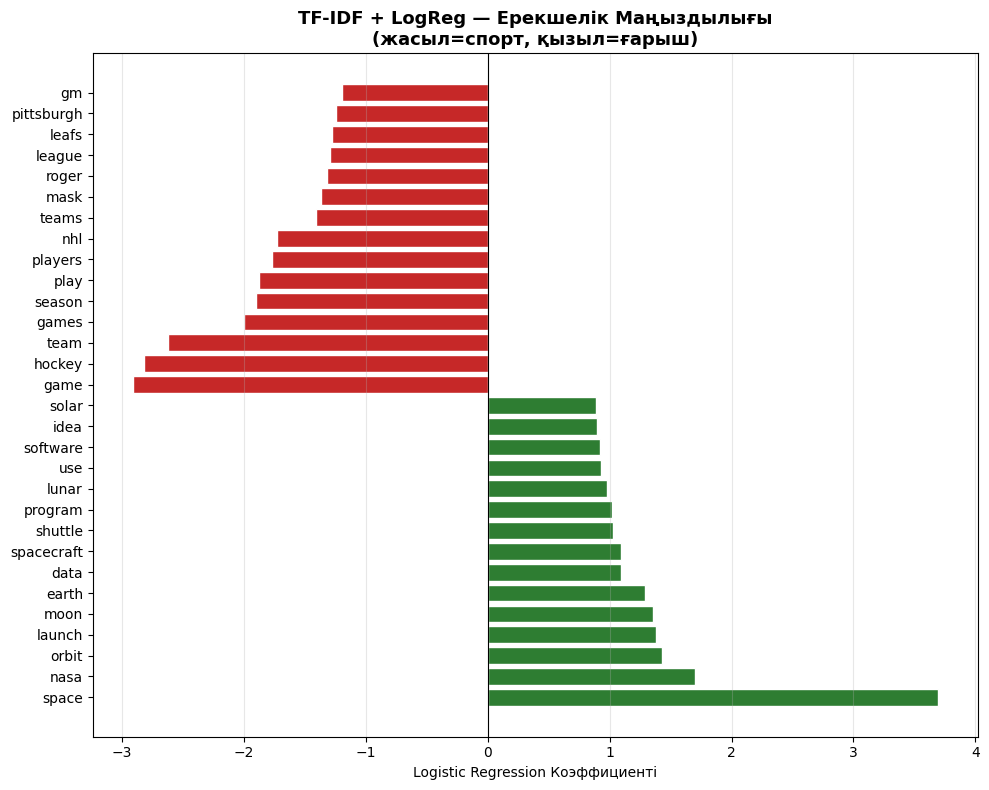

In [17]:
# ============================================================
### TODO ###
# Ерекшелік маңыздылығын горизонтал bar chart-та бейнелеңіз.
# Жоғарғы жəне төменгі 15 сөзді бір графикте бейнелеңіз.
# Позитив коэффициентті жасыл, негативті қызыл рəңмен белгілеңіз.
# ============================================================
top_idx    = np.concatenate([top_pos_idx, top_neg_idx])
top_words  = [feature_names[i] for i in top_idx]
top_coefs  = [coef[i] for i in top_idx]
top_colors = ['#2e7d32' if c > 0 else '#c62828' for c in top_coefs]

plt.figure(figsize=(10, 8))
plt.barh(
    top_words,
    top_coefs,
    color=top_colors,
    edgecolor='white'
)   # top_coefs
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('TF-IDF + LogReg — Ерекшелік Маңыздылығы\n(жасыл=спорт, қызыл=ғарыш)',
          fontsize=13, fontweight='bold')
plt.xlabel('Logistic Regression Коэффициенті')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 7-бөлім: Naive Bayes пен Logistic Regression Салыстыруы

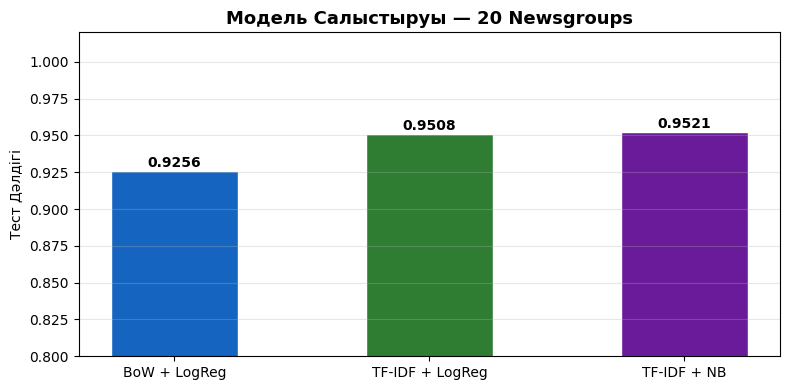

In [18]:
# ============================================================
### TODO ###
# MultinomialNB (Naive Bayes) классификаторын TF-IDF-пен біріктіріп
# Pipeline жасаңыз жəне үйретіңіз.
# Logistic Regression нəтижесімен салыстырыңыз.
# ============================================================
pipe_nb = Pipeline([
    ('vect', TfidfVectorizer(stop_words='english', max_features=5000)),
    ('clf',  MultinomialNB())
])
pipe_nb.fit(train_data.data, train_data.target)
acc_nb = accuracy_score(
    test_data.target,
    pipe_nb.predict(test_data.data)
)

results = {
    'BoW + LogReg':    acc_bow,
    'TF-IDF + LogReg': acc_tfidf,
    'TF-IDF + NB':     acc_nb,
}

plt.figure(figsize=(8, 4))
bars = plt.bar(results.keys(), results.values(),
               color=['#1565c0','#2e7d32','#6a1b9a'], edgecolor='white', width=0.5)
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', fontweight='bold')
plt.ylim(0.8, 1.02)
plt.title('Модель Салыстыруы — 20 Newsgroups', fontsize=13, fontweight='bold')
plt.ylabel('Тест Дəлдігі')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 8-бөлім: Рефлексиялық Сұрақтар

**Сұрақ 1.** BoW-тың ең басты кемшілігі қандай? Мəтіннің қандай ақпараты жоғалады?

> BoW-тың негізгі кемшілігі — сөздердің орналасу ретін ескермейді. Сондықтан сөйлемнің синтаксистік құрылымы мен контексті жоғалады.

**Сұрақ 2.** TF-IDF `the`, `is`, `a` сияқты жиі сөздерге неге төмен мəн береді?

> the, is, a сияқты сөздер көптеген құжаттарда кездеседі. Сондықтан олардың IDF мәні төмен болады, нәтижесінде TF-IDF салмағы да азаяды. Бұл модельге маңызды сөздерге көбірек назар аударуға мүмкіндік береді.

**Сұрақ 3.** N-gram ерекшеліктерін қосу vocabulary өлшемін күрт арттырады. Бұл қандай проблема туғызуы мүмкін?

> Vocabulary өлшемі өте үлкен болып кетеді, соның салдарынан:

жады шығыны артады;
модельді үйрету баяулайды;
артық үйрену (overfitting) қаупі өседі;
сирек кездесетін n-gram саны көбейеді.

**Сұрақ 4.** Ерекшелік маңыздылығы графигінде байқалған сөздер логикалы ма? Неліктен?

> Иә, әдетте логикалық болады. Мысалы:

спорт санатында: team, game, season, player, hockey;
ғарыш санатында: space, orbit, nasa, launch, moon.

Модель әр санатты ажыратуға көмектесетін сөздерге үлкен коэффициент береді.

**Сұрақ 5.** BoW/TF-IDF-тің синонимдер мен полисемиямен (бір сөздің бірнеше мəні) жұмыс жасауда қандай шектеуі бар?

> BoW және TF-IDF семантиканы түсінбейді.

Мысалы:

car және automobile — мағынасы бірдей болса да әртүрлі сөз ретінде қарастырылады;
bank сөзі өзен жағасын да, банк мекемесін де білдіруі мүмкін, бірақ модель контекстті ескермейді.

Сондықтан синонимдер мен көпмағыналы сөздермен жұмыс істеуде олардың мүмкіндігі шектеулі. Word2Vec, FastText, GloVe немесе Transformer модельдері бұл мәселені жақсырақ шешеді.

## Қорытынды

Осы зертханада сіз BoW матрицасын формула бойынша қолмен жасадыңыз, TF-IDF мəнін есептеп sklearn нəтижесімен тексердіңіз, N-gram ерекшеліктерін (bigram, trigram) Pipeline-ға қостыңыз, 20 Newsgroups деректерінде мəтін классификациясы жүргіздіңіз, жəне ерекшелік маңыздылығын визуализациялап Naive Bayes пен LogReg нəтижелерін салыстырдыңыз.

<div style="background-color:#e8f5e9; border-left:5px solid #2e7d32; padding:12px 16px; border-radius:6px; margin-top:16px;">
<strong>Келесі қадам:</strong> Зертханалық Жұмыс 3 — Word2Vec: сөздерді тығыз семантикалық кеңістікке орналастыру.
</div>